In [1]:
!pip install plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.6/15.6 MB 29.3 MB/s eta 0:00:0000:0100:01


In [1]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from scipy.stats import poisson
from sklearn.neighbors import KernelDensity
import time
import dill
from scipy.optimize import minimize
import pickle
import itertools
import os
import plotly.express as px
import time
from sklearn.metrics.cluster import adjusted_rand_score

In [90]:
fn = '../../Subclustering/MNPO/SAM_RI_joined_cleaned_08032026_sssubclass_MNPO.h5ad'

sam = SAM()
sam.load_data(fn)

In [91]:
sam_test = SAM()
sam_test.load_data('../../Active_SAM_joined/SAM_RI_joined_soupx_cleaned_01142026.h5ad')

In [92]:
sam_test.adata.obs.columns

Index(['n_genes', 'n_counts', 'key', 'leiden_clusters',
       'subclass_id_label_mapping', 'subclass_id_label_lc',
       'subclass_id_label_mapping_nounlabeled', 'subclass_id_label_crossed',
       'subclass_id_label_crossed_nn', 'subclass_lc', 'ss_subclass',
       'ss_subclass_nn', 'ss_subclass_nounlabeled_nn',
       'ss_subclass_crossed_nn', 'ss_subclass_nounlabeled_nn_agrp'],
      dtype='object')

In [93]:
tester = sam_test.adata.X[sam_test.adata.obs['ss_subclass'] == '116 AVPV-MEPO-SFO Tbr1 Glut']

In [94]:
tester

<432x23867 sparse matrix of type '<class 'numpy.float32'>'
	with 519679 stored elements in Compressed Sparse Row format>

In [95]:
sam.adata.X

<432x23867 sparse matrix of type '<class 'numpy.float32'>'
	with 519679 stored elements in Compressed Sparse Row format>

In [96]:
def csr_equal(A, B):
    if A.shape != B.shape:
        return False
    return (A != B).nnz == 0

In [97]:
csr_equal(tester,sam.adata.X)

True

In [98]:
sam.clustering(param =0.25)

In [99]:
sm = load_samap('../../Subclustering/MNPO/sm_hypoorgs_MNPO_08042026.pkl')

In [100]:
org_two = 'ri'

In [101]:
sm.sams[org_two].clustering(param =0.25)

In [102]:
sm.sams[org_two].adata.obs.columns

Index(['n_genes', 'n_counts', 'key', 'leiden_clusters',
       'subclass_id_label_mapping', 'subclass_id_label_lc',
       'subclass_id_label_mapping_nounlabeled', 'subclass_id_label_crossed',
       'subclass_id_label_crossed_nn', 'subclass_lc', 'ss_subclass',
       'ss_subclass_nn', 'ss_subclass_nounlabeled_nn',
       'ss_subclass_crossed_nn', 'ss_subclass_nounlabeled_nn_agrp',
       'eq_supertype_cl_v4', 'eq_clusters_v4'],
      dtype='object')

In [103]:
keys = {'mg':'eq_supertype_cl_v2',org_two:'leiden_clusters'}
D,MappingTable = get_mapping_scores(sm,keys)

lim_MappingTable = MappingTable.filter(like='mg_')
lim_MappingTable = lim_MappingTable[lim_MappingTable.index.str.contains(org_two + '_')]

/scratch/miniconda/lib/python3.7/site-packages/samap/analysis.py:1609: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead.  To get a de-fragmented frame, use `newframe = frame.copy()`
  samap.adata.obs[l] = pd.Categorical(cl)


In [104]:
lim_MappingTable

,mg_MM_Brs3,mg_MM_Foxp2_1,mg_MM_Foxp2_2,mg_MM_Thirst,mg_MM_Warmth
ri_0,0.011957,0.008512,0.043353,0.478815,0.107024
ri_1,0.381454,0.139914,0.003893,0.027878,0.161699
ri_2,0.013254,0.460093,0.238041,0.021797,0.009626
ri_3,0.000295,0.000000,0.000000,0.000000,0.916182
ri_4,0.360541,0.000108,0.000000,0.000183,0.115856


In [105]:
csr_equal(sam.adata.X,sm.sams[org_two].adata.X)

True

In [106]:
fin_mapping = {}
for item in lim_MappingTable.index:
    bm = lim_MappingTable.loc[item,:].idxmax()
    if lim_MappingTable.loc[item,bm] > .2:
        fin_mapping[item] = bm
    else:
        fin_mapping[item] = item
        
fin_labels = []
for item in sm.sams[org_two].adata.obs['leiden_clusters']:
    fin_labels.append(fin_mapping[org_two + '_' + str(item)][3:])

In [107]:
sam.adata.obs['fin_test'] = fin_labels

In [108]:
mg_genes = ['Etv1','Onecut1','Bcl11a','Foxp2','Ebf1','Emx2','Adcyap1','Agtr1a','Rxfp1','Crh','Trpc3','Sncg', 'Opn5','Rxfp2','Npy','Brs3','Ucn3','Slc2a9']
mo_genes = ['Etv1','Onecut1','Bcl11a','Foxp2','Ebf1','Emx2','Adcyap1','ENSMOCG00000019499','Rxfp1','Crh','Trpc3','Sncg', 'Opn5','Rxfp2','Npy','Brs3','UCN3','Slc2a9']
cj_genes = ['ETV1','ONECUT1','BCL11A','FOXP2','EBF1','EMX2','ADCYAP1','AGTR1','RXFP1','CRH','TRPC3','SNCG','OPN5','ENSCJPG00005003031','NPY','BRS3','SLC2A9']
ac_genes = ['etv1','bcl11a','ebf1','emx2','adcyap1','rxfp1','crh','trpc3','sncg','LOC100554017','LOC100553533','npy','brs3','ucn3','slc2a9']
ri_genes = ['LOC138641708','ONECUT1','BCL11A','FOXP2','EBF1','EMX2','ADCYAP1','LOC138638365','RXFP1','CRH','TRPC3','SNCG', 'OPN5','RXFP2','NPY','BRS3','UCN3','SLC2A9']

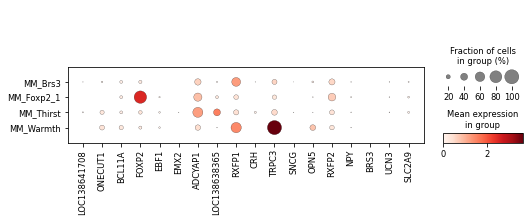

In [109]:
sc.pl.dotplot(sam.adata,groupby = 'fin_test',var_names=ri_genes)

In [110]:
sam.adata.obs

,n_genes,n_counts,key,leiden_clusters,subclass_id_label_mapping,subclass_id_label_lc,subclass_id_label_mapping_nounlabeled,subclass_id_label_crossed,subclass_id_label_crossed_nn,subclass_lc,ss_subclass,ss_subclass_nn,ss_subclass_nounlabeled_nn,ss_subclass_crossed_nn,ss_subclass_nounlabeled_nn_agrp,fin_test,eq_supertype_cl_v4,eq_clusters_v4
AACAACCGTCGCTGCA Run 18 sample 2,1271,2402.0,Run 18 sample 2,2,116 AVPV-MEPO-SFO Tbr1 Glut,120,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,120,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,MM_Foxp2_1,MM_Foxp2_1,2
AACCAACGTCACTCTC Run 18 sample 2,3047,7726.0,Run 18 sample 2,0,116 AVPV-MEPO-SFO Tbr1 Glut,147,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,147,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,MM_Thirst,MM_Thirst,0
AACCAACTCATACAGC Run 18 sample 2,5107,17273.0,Run 18 sample 2,1,116 AVPV-MEPO-SFO Tbr1 Glut,120,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,120,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,MM_Brs3,MM_Brs3,1
AACCTGAAGCTACTGT Run 18 sample 2,3974,11985.0,Run 18 sample 2,1,116 AVPV-MEPO-SFO Tbr1 Glut,120,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,120,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,MM_Brs3,MM_Brs3,1
AAGACAAGTACCAGAG Run 18 sample 2,1618,2899.0,Run 18 sample 2,2,116 AVPV-MEPO-SFO Tbr1 Glut,120,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,120,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,MM_Foxp2_1,MM_Foxp2_1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCCGGGAAGTCACTAC Run 18 sample 10,3025,6620.0,Run 18 sample 10,3,116 AVPV-MEPO-SFO Tbr1 Glut,147,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,147,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,MM_Warmth,MM_Warmth,3
TCGTAGAAGGCCTTGC Run 18 sample 10,1570,2572.0,Run 18 sample 10,2,116 AVPV-MEPO-SFO Tbr1 Glut,120,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,120,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,MM_Foxp2_1,MM_Foxp2_1,2
TCGTAGATCACTCTTA Run 18 sample 10,2324,4974.0,Run 18 sample 10,0,116 AVPV-MEPO-SFO Tbr1 Glut,120,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,120,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,MM_Thirst,MM_Thirst,0
TGAGACTAGGTAGCAC Run 18 sample 10,2632,5366.0,Run 18 sample 10,0,116 AVPV-MEPO-SFO Tbr1 Glut,147,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,147,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,116 AVPV-MEPO-SFO Tbr1 Glut,MM_Thirst,MM_Thirst,0


In [111]:
sam.adata.obs['fin_test'].equals(sam.adata.obs['eq_supertype_cl_v4'])

True

In [112]:
fin_labels = []
for item in sm.sams[org_two].adata.obs['leiden_clusters']:
    fin_labels.append(fin_mapping[org_two + '_' + str(item)][3:])

In [113]:
sam.adata.obs['eq_supertype_cl_v4'] = fin_labels
sm.sams[org_two].adata.obs['eq_supertype_cl_v4'] = fin_labels

In [114]:
sam.adata.obs['eq_clusters_v4'] = sm.sams[org_two].adata.obs['leiden_clusters']
sm.sams[org_two].adata.obs['eq_clusters_v4'] = sm.sams[org_two].adata.obs['leiden_clusters']

In [115]:
sam.save_anndata(fn)

In [116]:
save_samap(sm,'../../Subclustering/MNPO/sm_hypoorgs_MNPO_08042026.pkl')